In [236]:
import numpy as np
from matplotlib import pyplot as plt

In [237]:
def w(h):
    return (h**(-5)/5 + h**(-2)/2)
def dw(h):
    return (- h**(-6) + h**(-3))
def ddw(h):
    return (6*h**(-7) - 3*h**(-4))

# Robin BC

In [238]:
# Continuation to compute h0in for different values of hmax or h0out
data = np.loadtxt(
    "continuation/2D_continuation.txt",
    delimiter=',',
    unpack=True
)
numrows = len(data[0,:])
K1 = data[1:, numrows-8]
K2 = data[1:, numrows-7]
GradW1 = data[1:, numrows-6]
GradW2 = data[1:, numrows-5]
h0out_lim = data[1:, numrows-4]
hmax = data[1:, numrows-10]
h0out_formula = data[1:, numrows-9]
V = data[1:, numrows-11]
I = data[1:, numrows-12]
K = data[1:, numrows-13]
Omega = data[1:, numrows-14]
# Continuation (need to remove by hand (why???) the unstable branch)
par = data[1:, 3]
index = data[1:, 0]

i_branch = 16

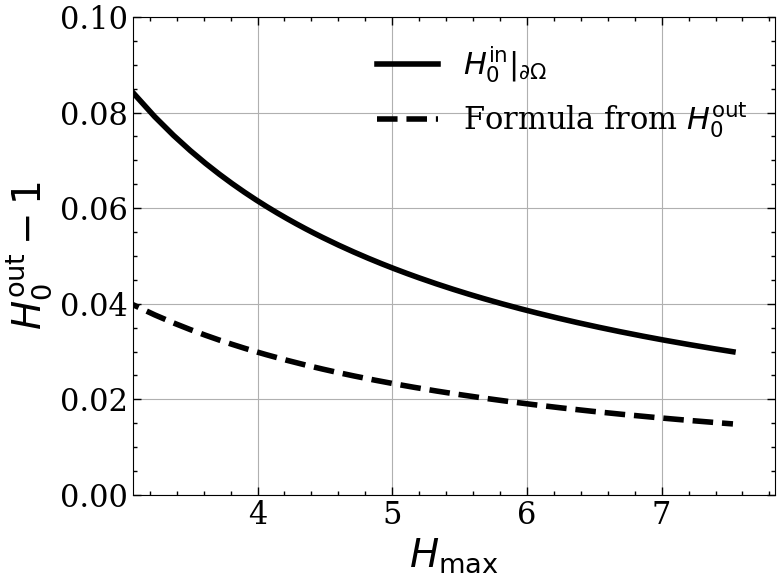

In [239]:
plt.plot(hmax,h0out_lim-1, label='$H_0^{\\mathrm{in}}|_{\\partial\\Omega}$', color='black')
plt.plot(hmax,h0out_formula-1, label='Formula from $H_0^{\\mathrm{out}}$', color='black',ls='--')
#plt.xlim(2,6)
plt.ylim(0,0.1)
plt.xlabel('$H_{\\mathrm{max}}$')
plt.ylabel('$H_0^{\\mathrm{out}}-1$')
plt.legend()
plt.grid()
plt.xlim(left=hmax[i_branch])
plt.show()

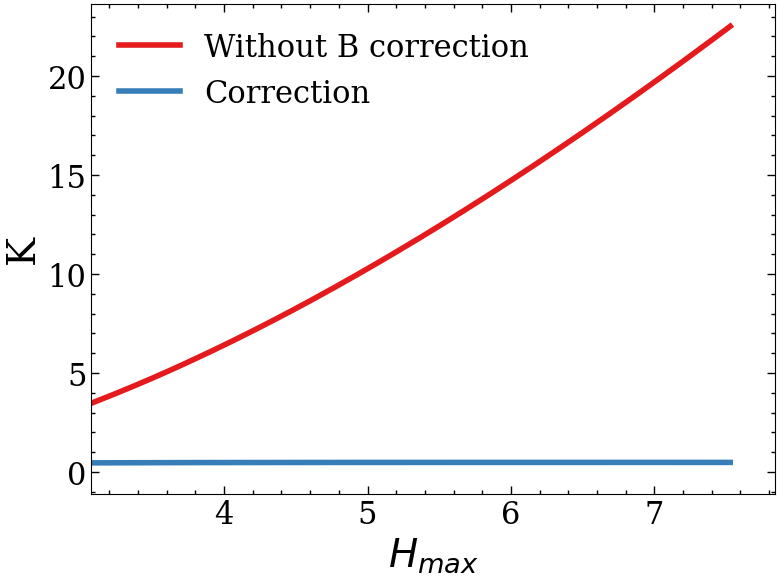

In [240]:
plt.plot(hmax,K1,label='Without B correction')
plt.plot(hmax,K2,label='Correction')
plt.xlim(left=hmax[i_branch])
plt.xlabel('$H_{max}$')
plt.ylabel('K')
plt.legend()

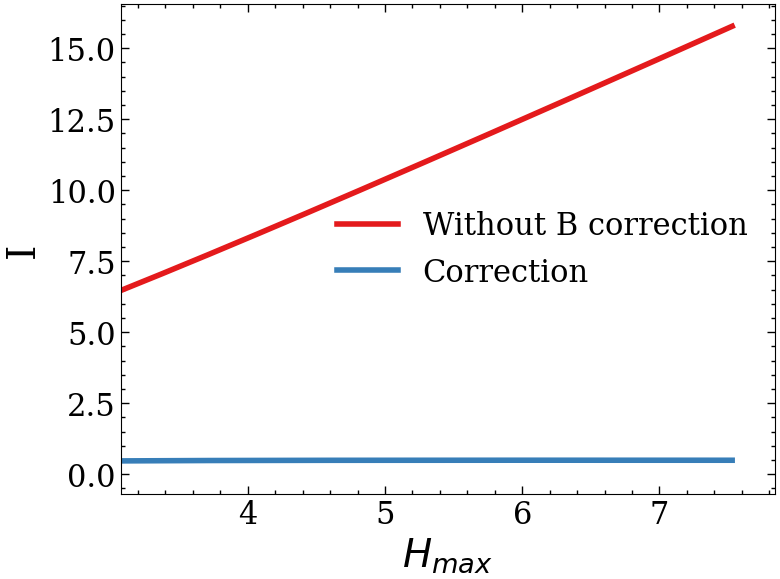

In [241]:
plt.plot(hmax,GradW1,label='Without B correction')
plt.plot(hmax,GradW2,label='Correction')
plt.xlim(left=hmax[i_branch])
plt.xlabel('$H_{max}$')
plt.ylabel('I')
plt.legend()

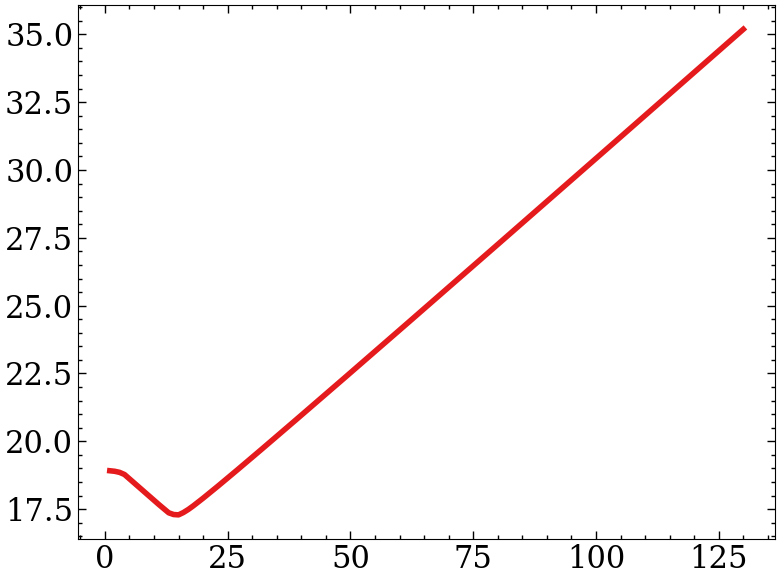

In [242]:
# The beginning of the branch is unstable!
plt.plot(index,par)

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_71215/1873104588.py:25: SyntaxWarning: invalid escape sequence '\m'
  ax_top.set_xlabel(r'$H_0^{\mathrm{out}}-1$')


(1, 500)

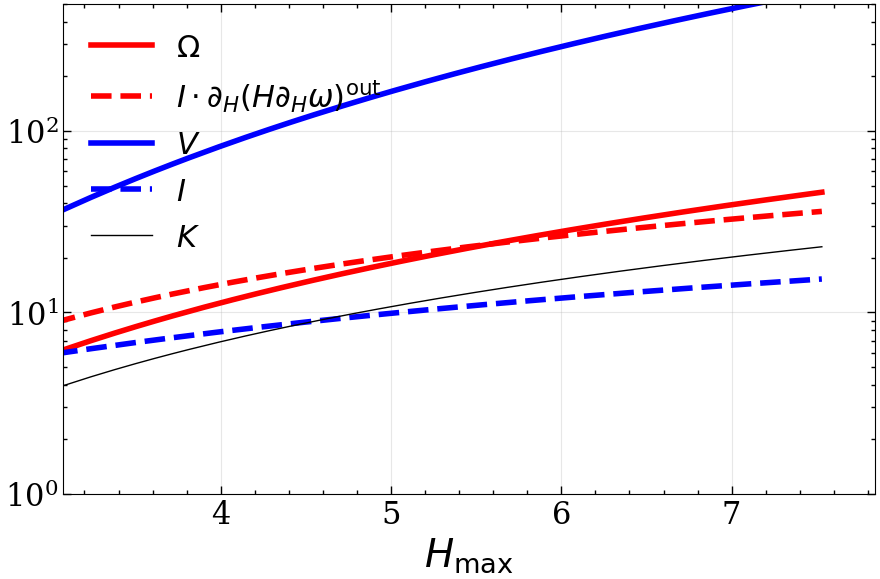

In [243]:
fig, ax = plt.subplots(figsize=(9, 6))
from matplotlib.ticker import FormatStrFormatter


# Bottom x-axis
ax.plot(hmax, Omega, label=r'$\Omega$',color='red')
ax.semilogy(hmax,I*(dw(h0out_lim)+h0out_lim*ddw(h0out_lim)), label='$I \\cdot \\partial_H(H\\partial_H \\omega)^{\\mathrm{out}}$', color='red',ls='--')
ax.plot(hmax, V,     label=r'$V$',color='blue')
ax.plot(hmax, I,     label=r'$I$',color='blue',ls='--')
ax.plot(hmax, K,     label=r'$K$',color='black',lw=1)

ax.set_xlabel(r'$h_{\max}$')
"""
# Top x-axis
ax_top = ax.twiny()

ax_top.set_xlim(ax.get_xlim())
n_ticks = 10
idx = np.linspace(0, len(h0out_lim) - 1, n_ticks, dtype=int)

ax_top.set_xticks(h0out_lim[idx]-1)
ax_top.set_xticklabels(h0out_lim[idx]-1)
ax_top.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax_top.set_xlabel(r'$H_0^{\mathrm{out}}-1$')
"""
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel(r'$H_{\mathrm{max}}$')
#ax.set_xlim(2,6)
plt.xlim(left=hmax[i_branch])
ax.set_ylim(1,500)

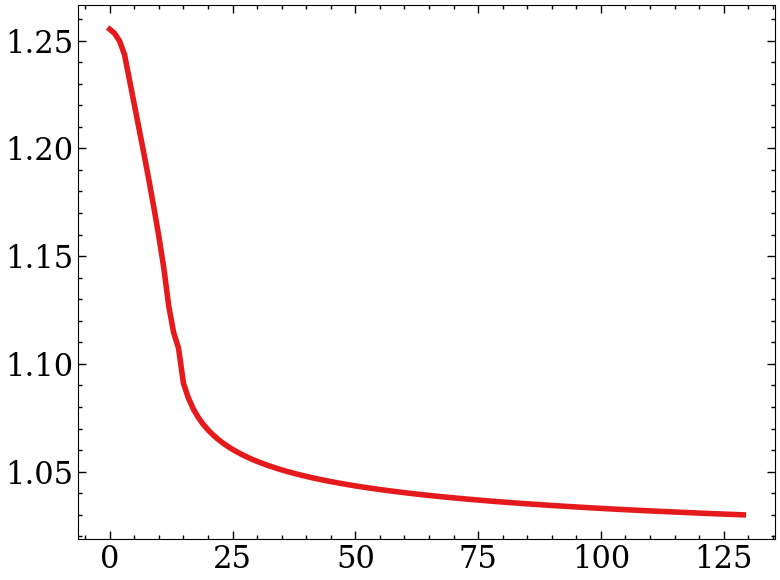

In [244]:
plt.plot(h0out_lim)